In [1]:
import numpy as np
from desc.objectives import TrappedResonance
from desc.equilibrium import Equilibrium
import matplotlib.pyplot as plt

In [29]:
eq = Equilibrium.load("wout_v20250319_v3_LowShear_000_000000_desc.h5")

num_eta = 20
Ekin_frac = 1
num_pitch = 2

s_min = 0.01
s_max = 0.9
pp = 0
qq = 1

data = np.load("wout_v20250319_v3_LowShear_000_000000_desc_poincare_data_Bcrit_4.98.npz",allow_pickle=True)

# Bcrit = 1/data['lam'][()]
pitch_invs = np.linspace(1/data['lam'][()],1/data['lam'][()] + 0.1,num_pitch)


rhos = np.linspace(s_min**0.5,s_max**0.5,20)
# s_prof = np.linspace(s_min, s_max, 20)
# rhos = np.sqrt(s_prof)

obj = TrappedResonance(
    eq, 
    rho=rhos, 
    num_eta=num_eta, 
    M=0, 
    N=1,
    pitch_invs=pitch_invs, 
    DEBUG=True,
    pitch_method=2, 
    num_pitch=num_pitch,
    num_well=4, 
    num_transit=2,
    knots_per_transit=100,
    num_quad=48, 
    KE_frac=np.array([Ekin_frac]),
    n_max=2,
    wd_blur=1.2,
    # Delta_Omega=0.002,
    STAB_SACRIFICE=False, # True = sacrifice Omega_eta' for numerical stability,
    bt_filter_flag=False,
    rt_filter_flag=False,
    CONSERVATIVE_IW=False, # which island width function, True = conservative version

)
obj.build()
val = obj.compute(eq.params_dict)

Precomputing transforms


In [30]:
res_arr = val['res_arr']
print(res_arr)
i_res = 0
print(res_arr[i_res])

[ 0.          1.         -1.          0.5        -0.5         2.
 -2.          3.         -3.          1.5        -1.5         4.
 -4.          2.5        -2.5         3.5        -3.5         3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265]
0.0


In [36]:
# np.savez("desc_debug.npz", val=val)
# val = np.load("desc_debug.npz",allow_pickle=True)['val'][()]
# valid = np.isfinite(val['Delta_s'][0,0,:])
# Delta_s = val['Delta_s'][0,0,valid]
# s_res = val['s_res'][0,0,valid]
# p_arr = val['p_arr'][valid]
# q_arr = val['q_arr'][valid]
# Omega = val['Omega'][:,0,0]
# res_weight = val['res_weight'][:,0,0,:] #(rho, pitch, well, res)

np.savez("desc_debug.npz", val=val)
val = np.load("desc_debug.npz",allow_pickle=True)['val'][()]
valid = np.isfinite(val['Delta_s_4'][0,0,:])
Delta_s_4 = val['Delta_s_4'][:,0,0,i_res]
print(Delta_s_4.shape)
# s_res = val['s_res'][valid]
# p_arr = val['p_arr'][valid]
q_arr = val['q_arr']
Omega = val['omega_arr'][:,0,0]
# res_weight = val['res_weight'][:,0,0]

(20,)


In [37]:
freq_data = np.load("wout_v20250319_v3_LowShear_000_000000_desc_trapped_frequencies.npz",allow_pickle=True)

Bcrit = 1/data['lam'][()]

omega_b = freq_data['omega_b_prof'][()]
omega_alpha = freq_data['omega_alpha_prof'][()]

Omega_firm3d = omega_alpha/omega_b
lam_values = freq_data['lam_values'][()]
lam_index = np.argmin(np.abs(1/lam_values - Bcrit))
Omega_firm3d = Omega_firm3d[lam_index]
s_firm3d = freq_data['s_prof'][()][lam_index]

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_1963845/695536645.py:5: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')


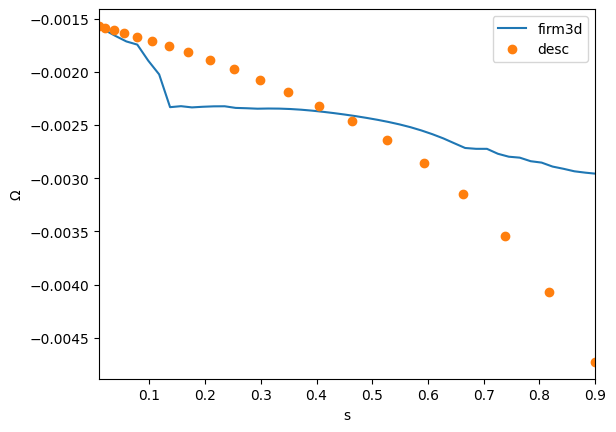

In [38]:
plt.figure()
plt.plot(s_firm3d,-Omega_firm3d,'-',label='firm3d')
plt.plot(rhos**2,Omega,'o',label='desc')
plt.xlabel('s')
plt.ylabel('$\Omega$')
plt.xlim(s_min,s_max)
plt.legend()
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1963845/3062153428.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\eta$')


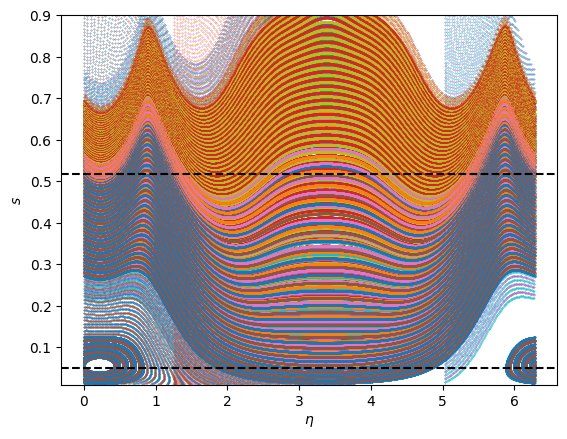

In [39]:
s_poinc = data['s_all']
etas_poinc = data['etas_all']

cross = 0.05

plt.figure()
for i in range(len(s_poinc)):
    plt.scatter(np.mod(etas_poinc[i],2*np.pi),s_poinc[i],s=0.1)
plt.ylim(s_min,s_max)
# plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)], color='k', linestyle='--')
# plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)] + 0.5*Delta_s[(p_arr == pp) & (q_arr == qq)], color='k', linestyle='--')
# plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)] - 0.5*Delta_s[(p_arr == pp) & (q_arr == qq)], color='k', linestyle='--')
Delta_s = 4 * (Delta_s_4) ** (1/4)
plt.axhline([cross], color='k', linestyle='--')
plt.axhline([cross+Delta_s[0]/2], color='k', linestyle='--')
plt.axhline([cross-Delta_s[0]/2], color='k', linestyle='--')

plt.xlabel('$\eta$')
plt.ylabel('$s$')
plt.show()

4